In [2]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input

I0000 00:00:1788604392.936395    2532 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788604422.688262    2532 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788604442.209644    2532 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
(x_train, y_train),(x_test, y_test) = keras.datasets.mnist.load_data()

In [4]:
print(x_train.shape)
print(x_train[1].shape)
print(x_test.shape)
print(x_test[1].shape)
print(y_train.shape)
print(y_test.shape)


(60000, 28, 28)
(28, 28)
(10000, 28, 28)
(28, 28)
(60000,)
(10000,)


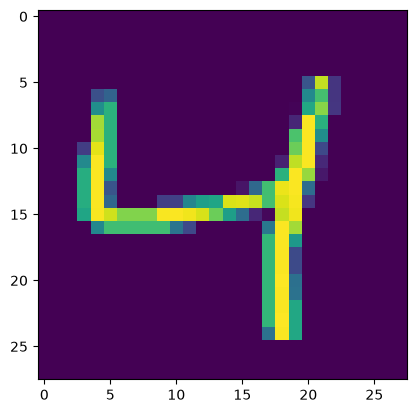

In [5]:
import matplotlib.pyplot as plt
plt.imshow(x_train[2])

In [6]:
x_train = x_train/255
x_test = x_test/255

In [7]:
model = Sequential()

model.add(Input(shape=(28,28)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation = 'softmax'))


E0000 00:00:1788604461.659460    2532 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(loss = 'sparse_categorical_crossentropy', optimizer ='Adam', metrics=['accuracy']) #If use categorial_rossentropy, we have to onehot encode our classes


In [10]:
history = model.fit(x_train,y_train, epochs=20, validation_split=0.2)

Epoch 1/20


W0000 00:00:1788604462.242782    2532 cpu_allocator_impl.cc:82] Allocation of 150528000 exceeds 10% of free system memory.


1489/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9164 - loss: 0.2936

W0000 00:00:1788604468.012860    2532 cpu_allocator_impl.cc:82] Allocation of 37632000 exceeds 10% of free system memory.


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9167 - loss: 0.2925 - val_accuracy: 0.9557 - val_loss: 0.1594
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9614 - loss: 0.1325 - val_accuracy: 0.9670 - val_loss: 0.1138
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9726 - loss: 0.0900 - val_accuracy: 0.9679 - val_loss: 0.1042
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9797 - loss: 0.0684 - val_accuracy: 0.9709 - val_loss: 0.0940
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9843 - loss: 0.0517 - val_accuracy: 0.9723 - val_loss: 0.0910
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9869 - loss: 0.0417 - val_accuracy: 0.9710 - val_loss: 0.0946
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9895 - loss: 0.0340 - val_accuracy: 0.9750 - val_loss: 0.0903
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9917 - loss: 0.0266 - val_accurac

In [11]:
y_prob = model.predict(x_test)

159/313 ━━━━━━━━━━━━━━━━━━━━ 0s 955us/step

W0000 00:00:1788604559.152881    2532 cpu_allocator_impl.cc:82] Allocation of 31360000 exceeds 10% of free system memory.


285/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [12]:
y_pred = y_prob.argmax(axis=1)

In [13]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9727

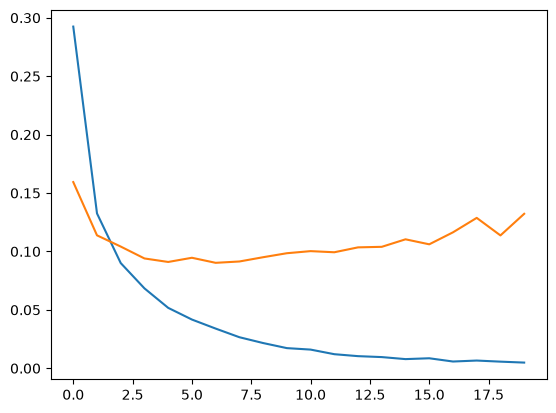

In [14]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

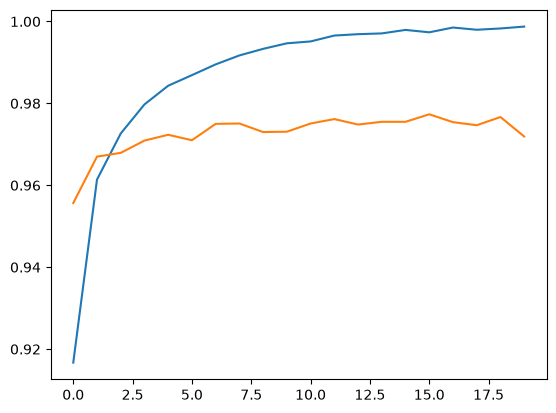

In [15]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

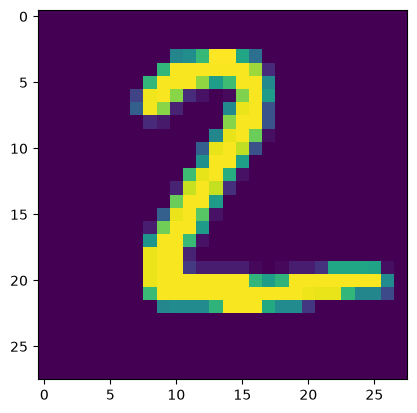

In [16]:
plt.imshow(x_test[1])

In [17]:
model.predict(x_test[1].reshape(1,28,28)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


array([2])

In [18]:
model1 = Sequential()

model1.add(Input(shape=(28,28)))
model1.add(Flatten())
model1.add(Dense(128, activation='relu'))
model1.add(Dense(128, activation='relu'))
model1.add(Dense(128, activation='relu'))
model1.add(Dense(10, activation = 'softmax'))

In [23]:
model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,794 (526.54 KB)

 Trainable params: 134,794 (526.54 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model1.compile(loss = 'sparse_categorical_crossentropy', optimizer ='Adam', metrics=['accuracy']) #If use categorial_rossentropy, we have to onehot encode our classes

In [25]:
history1 = model1.fit(x_train,y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9252 - loss: 0.2492 - val_accuracy: 0.9526 - val_loss: 0.1655
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9677 - loss: 0.1065 - val_accuracy: 0.9676 - val_loss: 0.1051
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9765 - loss: 0.0749 - val_accuracy: 0.9722 - val_loss: 0.0906
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9810 - loss: 0.0581 - val_accuracy: 0.9718 - val_loss: 0.0950
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9855 - loss: 0.0467 - val_accuracy: 0.9729 - val_loss: 0.1022
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9876 - loss: 0.0384 - val_accuracy: 0.9737 - val_loss: 0.1021
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9896 - loss: 0.0328 - val_accuracy: 0.9730 - val_loss: 0.1124
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9904 - loss: 0.0301 - 

In [26]:
y_prob = model1.predict(x_test)
y_pred = y_prob.argmax(axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [27]:
accuracy_score(y_test, y_pred)

0.9747

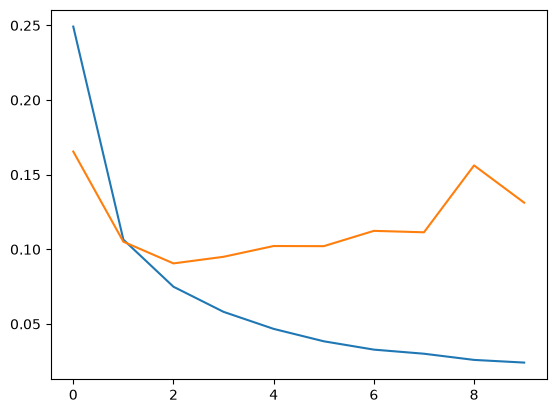

In [28]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

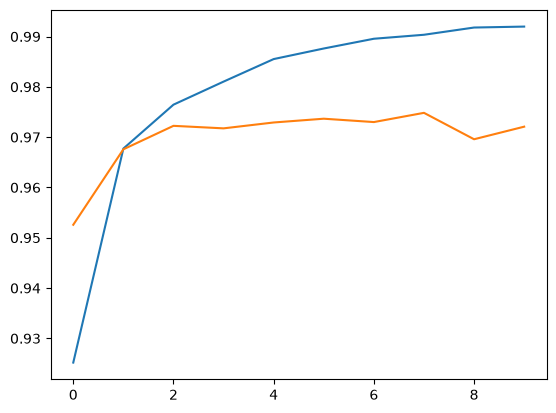

In [29]:
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])